# ASVspoof5 In-Gender Cross-System Transfer (A01-A04)

Evaluate each trained model (`A01..A04`) on every target system (`A01..A04`) within the same gender.

Example: model `A01` tested on `bonafide vs A02`, `bonafide vs A03`, `bonafide vs A04` (and optionally A01).


In [1]:
import io
import gc
import json
import pickle
import tarfile
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torchaudio

from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve

import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
# ===== Config =====
PROJECT_ROOT = Path('/home/SpeakerRec/BioVoice')

PLAN_BASE = (
    PROJECT_ROOT
    / "data"
    / "datasets"
    / "ASVspoof5_tars"
    / "ASVspoof5_protocols"
    / "gender_50spk_2000perclass_A01A04_outputs"
)
MANIFESTS = {
    'male': PLAN_BASE / 'male' / 'selected_utterances_plan.csv',
    'female': PLAN_BASE / 'female' / 'selected_utterances_plan.csv',
}

TRAIN_TAR_DIR = PROJECT_ROOT / 'data' / 'datasets' / 'ASVspoof5_tars' / 'ASVspoof5_audio_train_tars'
TRAINED_MODELS_BASE = PROJECT_ROOT / 'data' / 'models' / 'asvspoof5_train_gender_50spk_2000perclass_A01A04'
OUT_BASE = PROJECT_ROOT / 'data' / 'models' / 'asvspoof5_train_gender_50spk_2000perclass_A01A04_in_gender_cross_system_eval'
OUT_BASE.mkdir(parents=True, exist_ok=True)

SYSTEMS = ['A01', 'A02', 'A03', 'A04']
INCLUDE_SELF_TASK = False  # False => only other TTS; True => includes source==target

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
FORCE_RECOMPUTE_EMBEDDINGS = False
SAVE_PREDICTIONS = True

print('DEVICE =', DEVICE)
print('TRAINED_MODELS_BASE =', TRAINED_MODELS_BASE, '| exists =', TRAINED_MODELS_BASE.exists())
print('TRAIN_TAR_DIR =', TRAIN_TAR_DIR, '| exists =', TRAIN_TAR_DIR.exists())
print('OUT_BASE =', OUT_BASE)
for g, m in MANIFESTS.items():
    print(f'{g} manifest = {m} | exists =', m.exists())


DEVICE = cuda
TRAINED_MODELS_BASE = /home/SpeakerRec/BioVoice/data/models/asvspoof5_train_gender_50spk_2000perclass_A01A04 | exists = True
TRAIN_TAR_DIR = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_audio_train_tars | exists = True
OUT_BASE = /home/SpeakerRec/BioVoice/data/models/asvspoof5_train_gender_50spk_2000perclass_A01A04_in_gender_cross_system_eval
male manifest = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/gender_50spk_2000perclass_A01A04_outputs/male/selected_utterances_plan.csv | exists = True
female manifest = /home/SpeakerRec/BioVoice/data/datasets/ASVspoof5_tars/ASVspoof5_protocols/gender_50spk_2000perclass_A01A04_outputs/female/selected_utterances_plan.csv | exists = True


In [3]:
# ===== Load ReDimNet =====
redim_model = (
    torch.hub.load(
        'IDRnD/ReDimNet',
        'ReDimNet',
        model_name='b6',
        train_type='ptn',
        dataset='vox2',
    )
    .to(DEVICE)
    .eval()
)
print('Loaded ReDimNet on', DEVICE)


Using cache found in /home/SpeakerRec/.cache/torch/hub/IDRnD_ReDimNet_master


Loaded ReDimNet on cuda


In [4]:
def embed_waveform(wav: torch.Tensor, sr: int) -> np.ndarray:
    if sr != 16000:
        wav = torchaudio.functional.resample(wav, sr, 16000)
    if wav.ndim == 1:
        wav = wav.unsqueeze(0)
    if wav.shape[0] > 1:
        wav = wav[:1, :]
    wav = wav.to(DEVICE)
    with torch.no_grad():
        emb = redim_model(wav)
    return emb.squeeze(0).detach().cpu().numpy().astype(np.float32)


def embed_member_from_tar(tf: tarfile.TarFile, member: tarfile.TarInfo) -> np.ndarray:
    fobj = tf.extractfile(member)
    if fobj is None:
        raise RuntimeError(f'Cannot extract member: {member.name}')
    raw = fobj.read()
    try:
        wav, sr = torchaudio.load(io.BytesIO(raw))
    except Exception:
        import tempfile
        suffix = Path(member.name).suffix or '.flac'
        with tempfile.NamedTemporaryFile(suffix=suffix, delete=True) as tmp:
            tmp.write(raw)
            tmp.flush()
            wav, sr = torchaudio.load(tmp.name)
    return embed_waveform(wav, sr)


def extract_embeddings_for_manifest(manifest_df: pd.DataFrame, cache_npz: Path, force_recompute: bool = False):
    if cache_npz.exists() and not force_recompute:
        payload = np.load(cache_npz, allow_pickle=True)
        X = payload['X']
        utt_ids = payload['utt_ids'].astype(str)
        lut = pd.DataFrame({'utt_id': utt_ids, '_idx': np.arange(len(utt_ids))})
        m = manifest_df[['utt_id']].merge(lut, on='utt_id', how='left', validate='one_to_one')
        if m['_idx'].isna().any():
            miss = m.loc[m['_idx'].isna(), 'utt_id'].tolist()[:10]
            raise RuntimeError(f'Embedding cache missing utt_ids, examples={miss}')
        return X[m['_idx'].astype(int).to_numpy()]

    tars = sorted(TRAIN_TAR_DIR.glob('flac_T_*.tar'))
    assert len(tars) > 0, f'No train tar files in {TRAIN_TAR_DIR}'
    need = set(manifest_df['utt_id'].astype(str).tolist())
    emb_map = {}
    found = set()

    for tar_path in tars:
        print('Reading', tar_path.name)
        with tarfile.open(tar_path, 'r') as tf:
            for m in tf:
                if not m.isfile():
                    continue
                utt = Path(Path(m.name).name).stem
                if utt not in need or utt in found:
                    continue
                emb_map[utt] = embed_member_from_tar(tf, m)
                found.add(utt)
        print('Found so far:', len(found), '/', len(need))

    missing = sorted(list(need - found))
    if missing:
        raise RuntimeError(f'Missing {len(missing)} utt_ids in train tars. examples={missing[:10]}')

    ids = manifest_df['utt_id'].astype(str).tolist()
    X = np.stack([emb_map[u] for u in ids]).astype(np.float32)
    np.savez_compressed(cache_npz, X=X, utt_ids=np.array(ids, dtype=object))
    return X


def compute_metrics(y_true, p_spoof, thr=0.5):
    y_hat = (p_spoof >= thr).astype(int)
    cm = confusion_matrix(y_true, y_hat).tolist()
    out = {
        'accuracy': float(accuracy_score(y_true, y_hat)),
        'auc': float(roc_auc_score(y_true, p_spoof)) if len(np.unique(y_true)) == 2 else None,
        'confusion_matrix': cm,
        'classification_report': classification_report(y_true, y_hat, output_dict=True, zero_division=0),
    }
    try:
        fpr, tpr, thr_vals = roc_curve(y_true, p_spoof)
        out['roc'] = {'fpr': fpr.tolist(), 'tpr': tpr.tolist(), 'thresholds': thr_vals.tolist()}
    except Exception:
        out['roc'] = None
    return out


In [5]:
# ===== Build test embeddings per gender =====
test_manifest_by_gender = {}
X_test_by_gender = {}

for gender_name, manifest_path in MANIFESTS.items():
    df = pd.read_csv(manifest_path)
    req_cols = {'split', 'speaker_id', 'utt_id', 'gender', 'target_class'}
    missing = req_cols - set(df.columns)
    if missing:
        raise ValueError(f'{gender_name} manifest missing cols: {sorted(missing)}')

    df = df[df['target_class'].isin(['bonafide'] + SYSTEMS)].copy().reset_index(drop=True)
    df_test = df[df['split'].eq('test')].copy().reset_index(drop=True)
    if df_test.empty:
        raise RuntimeError(f'{gender_name}: empty test split')

    cache_dir = OUT_BASE / '_embedding_cache' / gender_name
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_npz = cache_dir / 'embeddings_test_only.npz'
    X_test = extract_embeddings_for_manifest(df_test[['utt_id']], cache_npz, force_recompute=FORCE_RECOMPUTE_EMBEDDINGS)

    test_manifest_by_gender[gender_name] = df_test
    X_test_by_gender[gender_name] = X_test

    print(f'{gender_name}: test rows =', len(df_test))


Reading flac_T_aa.tar
Found so far: 597 / 3000
Reading flac_T_ab.tar
Found so far: 1186 / 3000
Reading flac_T_ac.tar
Found so far: 1803 / 3000
Reading flac_T_ad.tar
Found so far: 2388 / 3000
Reading flac_T_ae.tar
Found so far: 3000 / 3000
male: test rows = 3000
Reading flac_T_aa.tar
Found so far: 638 / 3000
Reading flac_T_ab.tar
Found so far: 1213 / 3000
Reading flac_T_ac.tar
Found so far: 1828 / 3000
Reading flac_T_ad.tar
Found so far: 2395 / 3000
Reading flac_T_ae.tar
Found so far: 3000 / 3000
female: test rows = 3000


In [6]:
# ===== In-gender cross-system evaluation =====
rows = []

for gender_name in ['male', 'female']:
    print(f'\n===== {gender_name.upper()} =====')
    g_dir = OUT_BASE / gender_name
    g_dir.mkdir(parents=True, exist_ok=True)

    tgt_df = test_manifest_by_gender[gender_name]
    X_tgt_all = X_test_by_gender[gender_name]
    idx_map = pd.DataFrame({'utt_id': tgt_df['utt_id'].astype(str), '_idx': np.arange(len(tgt_df))})

    for source_system in SYSTEMS:
        source_model_dir = TRAINED_MODELS_BASE / gender_name / source_system
        scaler_path = source_model_dir / 'scaler.pkl'
        clf_path = source_model_dir / 'logistic_regression.pkl'
        if not scaler_path.exists() or not clf_path.exists():
            raise FileNotFoundError(f'Missing model artifacts in {source_model_dir}')

        with open(scaler_path, 'rb') as f:
            scaler = pickle.load(f)
        with open(clf_path, 'rb') as f:
            clf = pickle.load(f)

        for target_system in SYSTEMS:
            if (not INCLUDE_SELF_TASK) and (target_system == source_system):
                continue

            print(f'-- model {source_system} tested on bonafide vs {target_system}')
            task_df = tgt_df[tgt_df['target_class'].isin(['bonafide', target_system])].copy().reset_index(drop=True)
            if task_df.empty:
                raise RuntimeError(f'Empty task for {gender_name}: source={source_system}, target={target_system}')

            pick = task_df[['utt_id']].astype(str).merge(idx_map, on='utt_id', how='left', validate='one_to_one')
            if pick['_idx'].isna().any():
                raise RuntimeError(f'Index mapping failed for {gender_name}/{source_system}/{target_system}')

            X_te = X_tgt_all[pick['_idx'].astype(int).to_numpy()]
            y_te = np.where(task_df['target_class'].eq('bonafide'), 0, 1).astype(int)
            if set(np.unique(y_te)) != {0, 1}:
                raise RuntimeError(f'Target class imbalance in {gender_name}/{source_system}/{target_system}')

            X_te_s = scaler.transform(X_te)
            p_te = clf.predict_proba(X_te_s)[:, 1]
            m_te = compute_metrics(y_te, p_te, thr=0.5)

            pair_dir = g_dir / f'{source_system}_model_on_{target_system}_data'
            pair_dir.mkdir(parents=True, exist_ok=True)

            run_summary = {
                'gender_set': gender_name,
                'source_model_system': source_system,
                'target_eval_system': target_system,
                'test_rows': int(len(task_df)),
                'metrics_test_thr_0_5': m_te,
            }
            (pair_dir / 'run_summary.json').write_text(json.dumps(run_summary, indent=2), encoding='utf-8')

            if SAVE_PREDICTIONS:
                pred = task_df[['split', 'speaker_id', 'utt_id', 'gender', 'target_class']].copy().reset_index(drop=True)
                pred['label_id'] = y_te
                pred['prob_spoof'] = p_te
                pred['pred_label_id_thr_0_5'] = (p_te >= 0.5).astype(int)
                pred.to_csv(pair_dir / f'predictions_{source_system}_on_{target_system}.csv', index=False)

            if m_te['roc'] is not None:
                roc_df = pd.DataFrame({
                    'fpr': m_te['roc']['fpr'],
                    'tpr': m_te['roc']['tpr'],
                    'threshold': m_te['roc']['thresholds'],
                })
                roc_df.to_csv(pair_dir / 'roc_curve_points.csv', index=False)

            rows.append({
                'gender_set': gender_name,
                'source_model_system': source_system,
                'target_eval_system': target_system,
                'test_n': int(len(y_te)),
                'test_acc': m_te['accuracy'],
                'test_auc': m_te['auc'],
                'test_cm_00': int(m_te['confusion_matrix'][0][0]),
                'test_cm_01': int(m_te['confusion_matrix'][0][1]),
                'test_cm_10': int(m_te['confusion_matrix'][1][0]),
                'test_cm_11': int(m_te['confusion_matrix'][1][1]),
            })

            del X_te, y_te, X_te_s, p_te
            gc.collect()

summary_df = pd.DataFrame(rows).sort_values(['gender_set', 'source_model_system', 'target_eval_system']).reset_index(drop=True)
summary_csv = OUT_BASE / 'in_gender_cross_system_metrics_summary.csv'
summary_df.to_csv(summary_csv, index=False)
print('Saved:', summary_csv)
display(summary_df)



===== MALE =====
-- model A01 tested on bonafide vs A02
-- model A01 tested on bonafide vs A03
-- model A01 tested on bonafide vs A04
-- model A02 tested on bonafide vs A01
-- model A02 tested on bonafide vs A03
-- model A02 tested on bonafide vs A04
-- model A03 tested on bonafide vs A01
-- model A03 tested on bonafide vs A02
-- model A03 tested on bonafide vs A04
-- model A04 tested on bonafide vs A01
-- model A04 tested on bonafide vs A02
-- model A04 tested on bonafide vs A03

===== FEMALE =====
-- model A01 tested on bonafide vs A02
-- model A01 tested on bonafide vs A03
-- model A01 tested on bonafide vs A04
-- model A02 tested on bonafide vs A01
-- model A02 tested on bonafide vs A03
-- model A02 tested on bonafide vs A04
-- model A03 tested on bonafide vs A01
-- model A03 tested on bonafide vs A02
-- model A03 tested on bonafide vs A04
-- model A04 tested on bonafide vs A01
-- model A04 tested on bonafide vs A02
-- model A04 tested on bonafide vs A03
Saved: /home/SpeakerRec/Bi

,gender_set,source_model_system,target_eval_system,test_n,test_acc,test_auc,test_cm_00,test_cm_01,test_cm_10,test_cm_11
0,female,A01,A02,1200,0.992500,0.999967,591,9,0,600
1,female,A01,A03,1200,0.992500,0.999992,591,9,0,600
2,female,A01,A04,1200,0.983333,0.997597,591,9,11,589
3,female,A02,A01,1200,0.995000,0.999911,594,6,0,600
4,female,A02,A03,1200,0.995000,1.000000,594,6,0,600
5,female,A02,A04,1200,0.972500,0.996858,594,6,27,573
6,female,A03,A01,1200,0.988333,0.999317,586,14,0,600
7,female,A03,A02,1200,0.988333,0.999725,586,14,0,600
8,female,A03,A04,1200,0.970000,0.994664,586,14,22,578
9,female,A04,A01,1200,0.977500,0.998522,589,11,16,584


,gender_set,source_model_system,target_eval_system,test_n,test_acc,test_auc,test_cm_00,test_cm_01,test_cm_10,test_cm_11
0,female,A01,A02,1200,0.992500,0.999967,591,9,0,600
1,female,A01,A03,1200,0.992500,0.999992,591,9,0,600
2,female,A01,A04,1200,0.983333,0.997597,591,9,11,589
3,female,A02,A01,1200,0.995000,0.999911,594,6,0,600
4,female,A02,A03,1200,0.995000,1.000000,594,6,0,600
5,female,A02,A04,1200,0.972500,0.996858,594,6,27,573
6,female,A03,A01,1200,0.988333,0.999317,586,14,0,600
7,female,A03,A02,1200,0.988333,0.999725,586,14,0,600
8,female,A03,A04,1200,0.970000,0.994664,586,14,22,578
9,female,A04,A01,1200,0.977500,0.998522,589,11,16,584


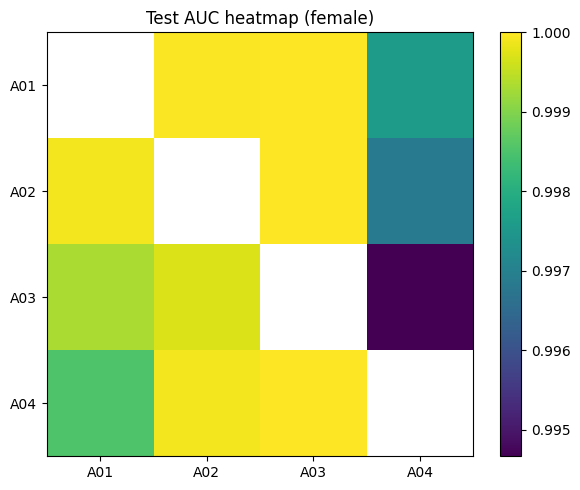

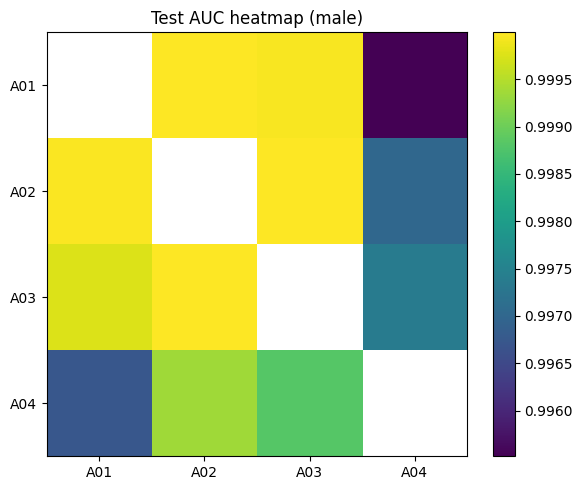

In [7]:
# ===== Quick plots =====
df = pd.read_csv(OUT_BASE / 'in_gender_cross_system_metrics_summary.csv')
display(df)

for gender_name, g in df.groupby('gender_set'):
    pivot_auc = g.pivot(index='source_model_system', columns='target_eval_system', values='test_auc')

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(pivot_auc.values, aspect='auto')
    ax.set_xticks(range(len(pivot_auc.columns)))
    ax.set_xticklabels(pivot_auc.columns)
    ax.set_yticks(range(len(pivot_auc.index)))
    ax.set_yticklabels(pivot_auc.index)
    ax.set_title(f'Test AUC heatmap ({gender_name})')
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
